In [33]:
import pandas as pd
ethiopia=pd.read_csv("../data/ethiopia_clean.csv")
kenya=pd.read_csv("../data/kenya.csv")
nigeria=pd.read_csv("../data/nigeria.csv")
sudan=pd.read_csv("../data/sudan.csv")
tanzania=pd.read_csv("../data/tanzania.csv")



In [34]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] ="kenya"
nigeria["Country"]="nigeria"
sudan["Country"] ="sudan"
tanzania["Country"] ="tanzania"

In [35]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,2015-01-01,1.0
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,2015-01-02,1.0
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,2015-01-03,1.0
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,2015-01-04,1.0
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,2015-01-05,1.0


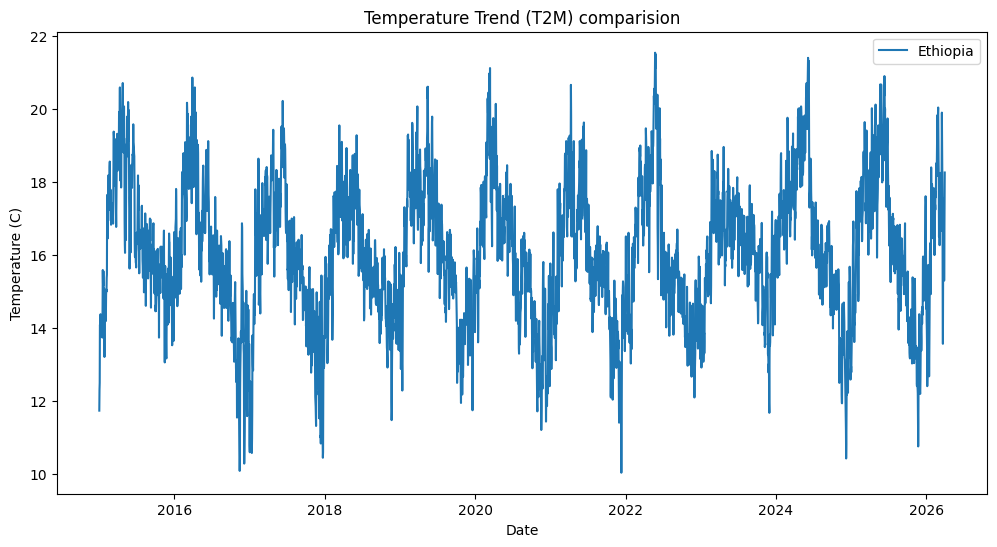

In [36]:
import matplotlib.pyplot as plt
#convert date if not already
df['date'] =pd.to_datetime(df['date'])
#group data
temp_trend = df.groupby(['date','Country']) ['T2M'].mean().reset_index()
#plot
plt.figure(figsize=(12,6))
for Country in temp_trend['Country'].unique(): 
    data = temp_trend[temp_trend['Country']==Country]
plt.plot(data['date'],
data['T2M'] , label=Country)
plt.title("Temperature Trend (T2M) comparision")
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.legend()
plt.show()



### Temperature Trend Comparison
This plot shws the monthly average temperature(T2M) for all five countries from 2015 to 2026
we observe that:
-Some countries show higher overall temperatures than others.
-There are visible seasonal patterns in temperature fluctuations.
-Differences between countries sugget varying climate conditions and warming trends.
This comparison helps identify which countries are experiencing stronger warming patterns.

In [37]:
temp_summary = df.groupby('Country') ['T2M'].agg(['mean','median','std'])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
kenya,20.427600,20.36,1.440824
nigeria,26.656928,26.82,1.123335
sudan,28.759007,29.16,4.681305
tanzania,26.802422,26.99,1.325388


In [38]:
precip_summary = df.groupby('Country')['PRECTOTCORR'].agg(['mean','median','std'])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
kenya,1.468162,0.38,3.180228
nigeria,4.213914,1.84,7.266742
sudan,0.643875,0.00,3.057672
tanzania,3.740256,0.64,8.003947


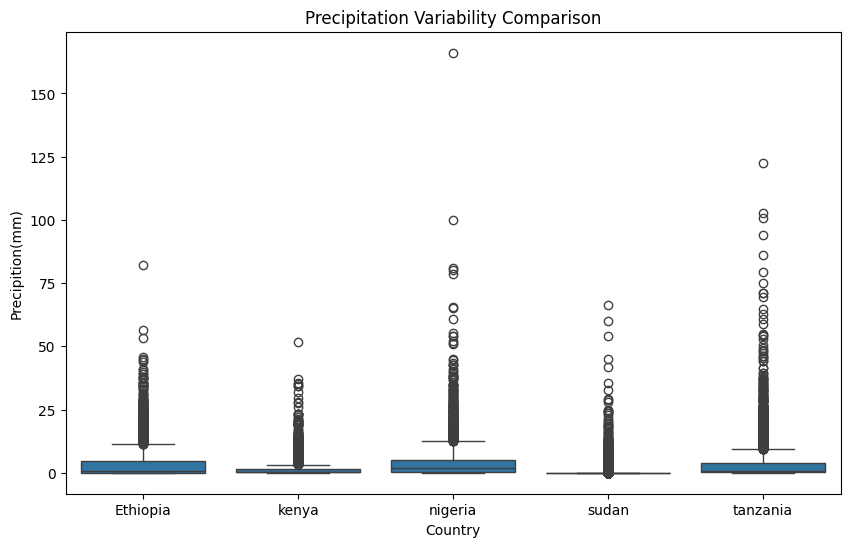

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.boxplot(x='Country',y='PRECTOTCORR', data=df)
plt.title("Precipitation Variability Comparison")
plt.xlabel("Country")
plt.ylabel("Precipition(mm)")
plt.show()


This boxplot compares percipitation distribution across countries.It shows variability,median levels, and presence of outliers, indicating differences in rainfall patterns.

In [40]:
extreme_heat = df[df['T2M_MAX']>35]
heat_counts = extreme_heat.groupby('Country').size()
heat_counts

Country
sudan    2694
dtype: int64

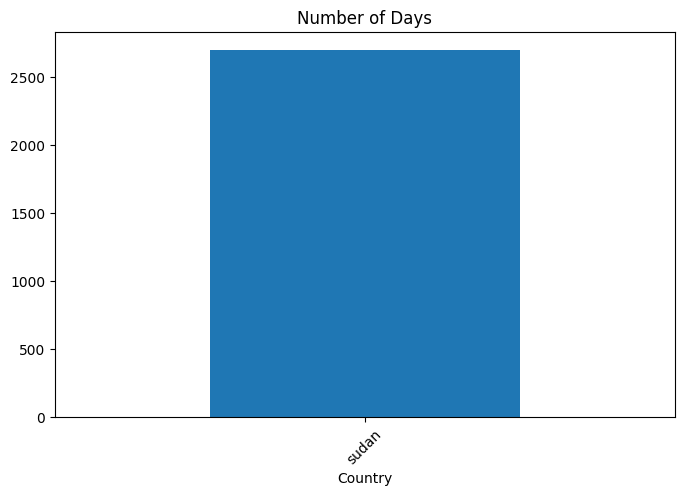

In [41]:
heat_counts.plot(kind='bar', figsize=(8,5))
plt.title("Extreme Heat Days (>35 degree C)")
plt.title("Number of Days")
plt.xticks(rotation=45)
plt.show()

In [42]:
dry_days= df[df['PRECTOTCORR']<1]
dry_counts= dry_days.groupby('Country').size()
dry_counts

Country
Ethiopia    2161
kenya       2831
nigeria     1595
sudan       3696
tanzania    2303
dtype: int64

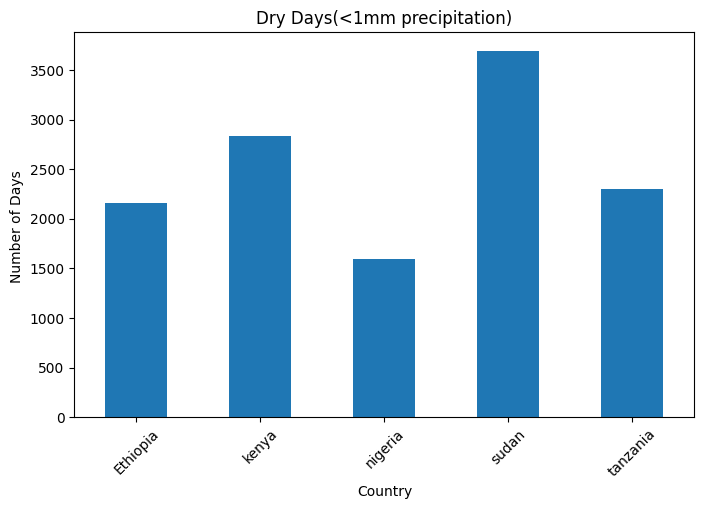

In [43]:
dry_counts.plot(kind='bar',figsize=(8,5))
plt.title("Dry Days(<1mm precipitation)")
plt.ylabel("Number of Days ")
plt.xticks(rotation=45)
plt.show()

-Countries with more extreme heat days face higher temperature stress.
-High number of dry days indicates drought risk.
-These factors are kry indicators of climate vulnerability.

In [46]:
import pandas as pd
#comnine key indicators into one table
vulnerability = pd.DataFrame({'Heat_Days': heat_counts, 'Dry_Days':dry_counts,'Temp_Mean':temp_summary['mean'],'precip_Variability':precip_summary['std']})
vulnerability= vulnerability.sort_values(by=['Heat_Days','Dry_Days','precip_Variability'],ascending=False)
vulnerability

,Heat_Days,Dry_Days,Temp_Mean,precip_Variability
Country,,,,
sudan,2694.0,3696,28.759007,3.057672
kenya,NaN,2831,20.427600,3.180228
tanzania,NaN,2303,26.802422,8.003947
Ethiopia,NaN,2161,16.068500,6.289061
nigeria,NaN,1595,26.656928,7.266742


Countries are ranked based on extreme heat, dry days , and rainfall variability. Higher values indicate greater climate vulnerability.